# I. Import and Setups

## I.1. Import Modules

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import pandas as pd
import itertools
from sklearn.metrics import classification_report
from tensorflow.keras.utils import plot_model

## I.2. Initialize Constant Variables

In [2]:
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE = 32
EPOCH = 100
N_CLASS = 14

# II. Importing Data and Exploring Data

## II.1. Importing Data

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    seed = 123,
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 1825 files belonging to 14 classes.


## II.2. Exploring Data

In [5]:
class_names = dataset.class_names
class_names

['bangku',
 'buah_kentang',
 'daun_kentang',
 'daun_mangga',
 'daun_tomat',
 'gelas',
 'laptop',
 'meja',
 'mobil',
 'motor',
 'orang',
 'proyektor',
 'sepatu',
 'tas']

In [6]:
objects_dir = "dataset"
objects = os.listdir(objects_dir)

In [7]:
nums = {}
for obj in objects:
    nums[obj] = len(os.listdir(objects_dir + '/' + obj))
    
# converting the nums dictionary to pandas dataframe passing index as plant name and number of images as column
img_per_class_df = pd.DataFrame(nums.values(), index=nums.keys(), columns=["No. of images"])

In [9]:
img_per_class_df.sample(N_CLASS).style.set_properties(**{'background-color': '#f9f9f9', 'color': '#4CAF50', 'font-weight': 'bold'})

,No. of images
orang,124
daun_kentang,139
sepatu,111
daun_tomat,141
buah_kentang,151
laptop,146
gelas,87
motor,125
proyektor,97
bangku,152


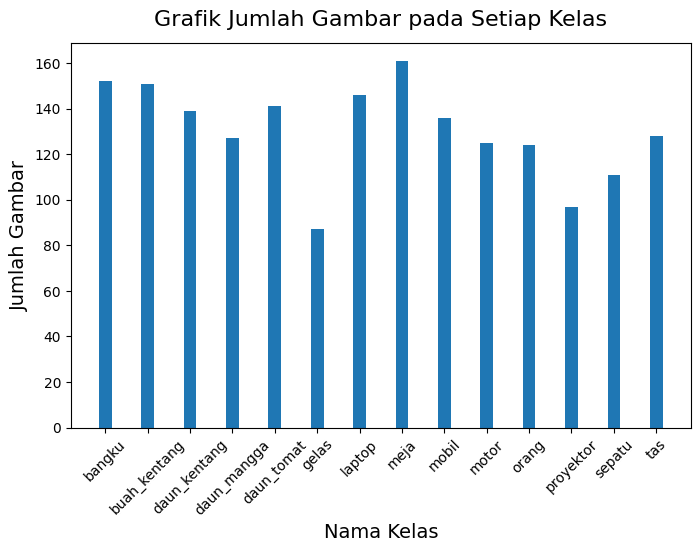

In [13]:
#plotting number of images available for each class
index = [n for n in range(N_CLASS)]
plt.figure(figsize=(8, 5))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Nama Kelas', fontsize=14)
plt.ylabel('Jumlah Gambar', fontsize=14)
plt.xticks(index, objects, fontsize=10, rotation=45)
plt.title('Grafik Jumlah Gambar pada Setiap Kelas', fontsize=16, pad=12)
plt.show()

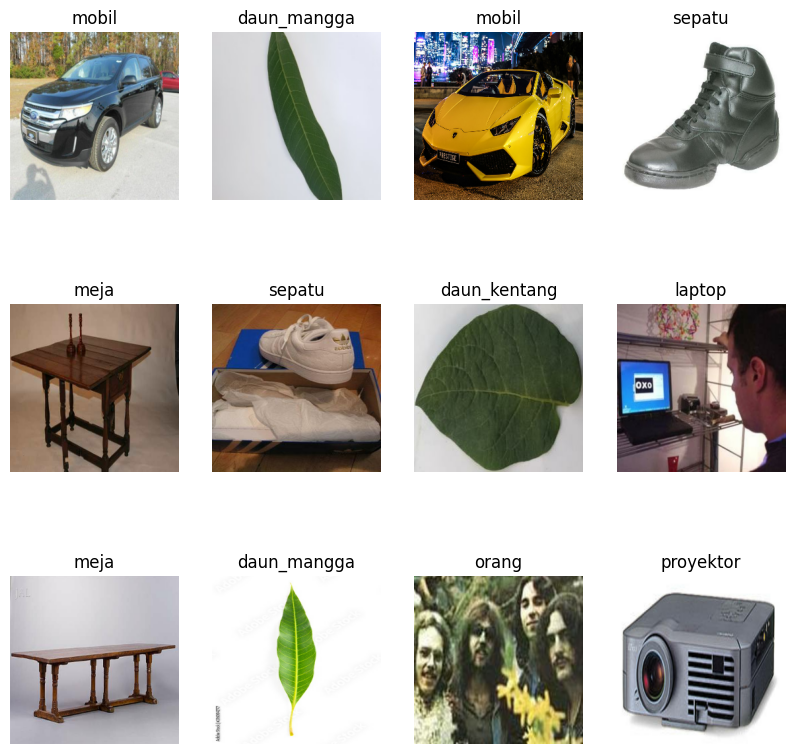

In [15]:
fig = plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")
fig.savefig('category_samples.png', dpi=300)

# III. Data Preparation

## III.1. Train-Val-Test Data Split

In [16]:
len(dataset)

58

In [17]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [18]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [19]:
len(train_ds)

46

In [20]:
len(val_ds)

5

In [21]:
len(test_ds)

7

## III.2. Optimize Tensorflow Pipeline Performance

In [22]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## III.3. Resize and Rescale

In [23]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

## III.4. Data Augmentation

### III.4.1. Initialize data augmentation method

In [24]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

### III.4.2. Applying Data Augmentation to Train Dataset

In [25]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

### III.4.3. Visualize Augmented Train Dataset

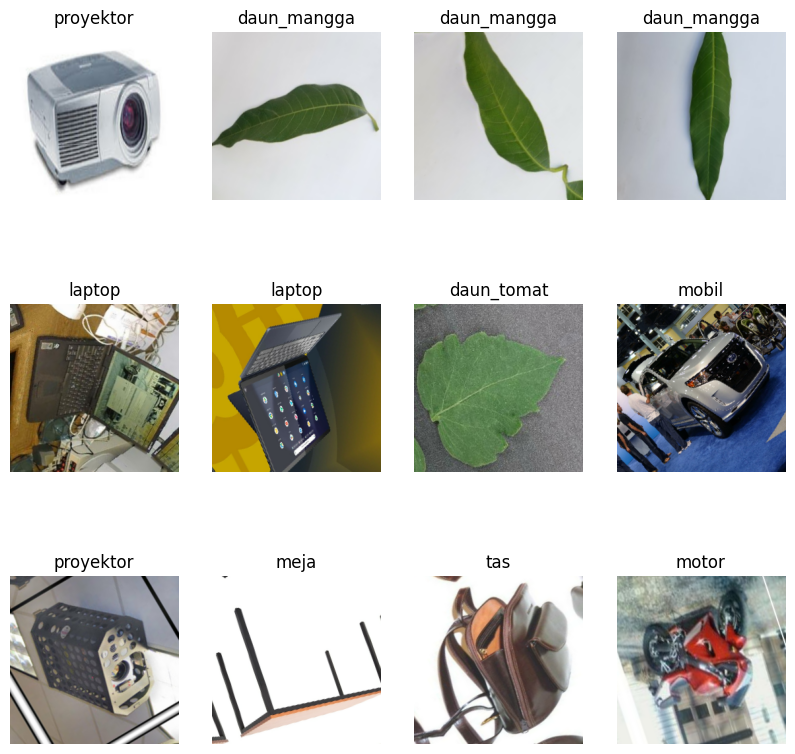

In [27]:
fig = plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")
fig.savefig('augmented_samples.png', dpi=300)

# IV. Model Creation

In [28]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn.build(input_shape=input_shape)

C:\Users\jo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 14)               │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,462 (720.55 KB)

 Trainable params: 184,462 (720.55 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_cnn.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [31]:
history = model_cnn.fit(
    train_ds,
    batch_size = BATCH_SIZE,
    validation_data = val_ds,
    epochs = EPOCH,
    verbose = 1
)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.0962 - loss: 2.6179 - val_accuracy: 0.1813 - val_loss: 2.4053
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2409 - loss: 2.2914 - val_accuracy: 0.4062 - val_loss: 1.8703
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.3434 - loss: 1.9580 - val_accuracy: 0.3938 - val_loss: 1.7824
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4252 - loss: 1.7357 - val_accuracy: 0.4625 - val_loss: 1.6784
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4246 - loss: 1.6520 - val_accuracy: 0.4875 - val_loss: 1.5941
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4575 - loss: 1.6015 - val_accuracy: 0.5750 - val_loss: 1.2987
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.4488 - loss: 1.4941 - val_accuracy: 0.6000 - val_loss: 1.2012
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5143 - loss: 1.4024 - val_accuracy: 0.5813 - v

# V. Model Evaluation

## a. Training-Validation Accuracy and Loss

In [32]:
acc_model = history.history['accuracy']
val_acc_model = history.history['val_accuracy']

loss_model = history.history['loss']
val_loss_model = history.history['val_loss']

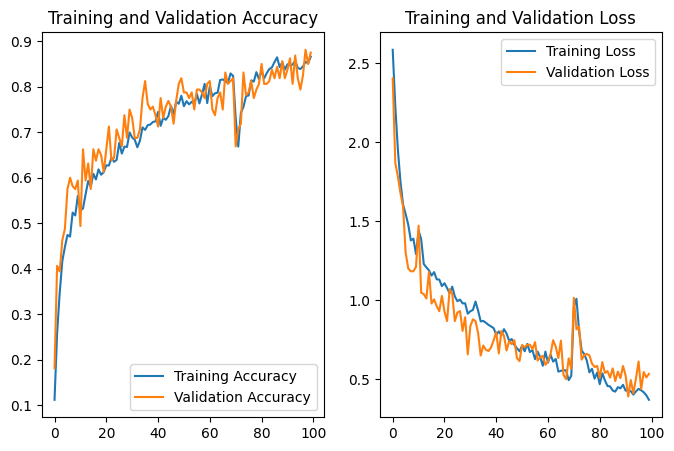

In [36]:
fig_trainVal_acc = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH), acc_model, label='Training Accuracy')
plt.plot(range(EPOCH), val_acc_model, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH), loss_model, label='Training Loss')
plt.plot(range(EPOCH), val_loss_model, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc.savefig('train_val_acc.png', dpi=300)

## b. Confusion Matrix

In [34]:
y_pred_model = []
y_true_model = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds:
    preds_model = model_cnn.predict(images)
    y_pred_model.extend(np.argmax(preds_model, axis=1))  # Get the index of the class with the highest probability
    y_true_model.extend(labels.numpy())  # Get the true labels

y_pred_model = np.array(y_pred_model)
y_true_model = np.array(y_true_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


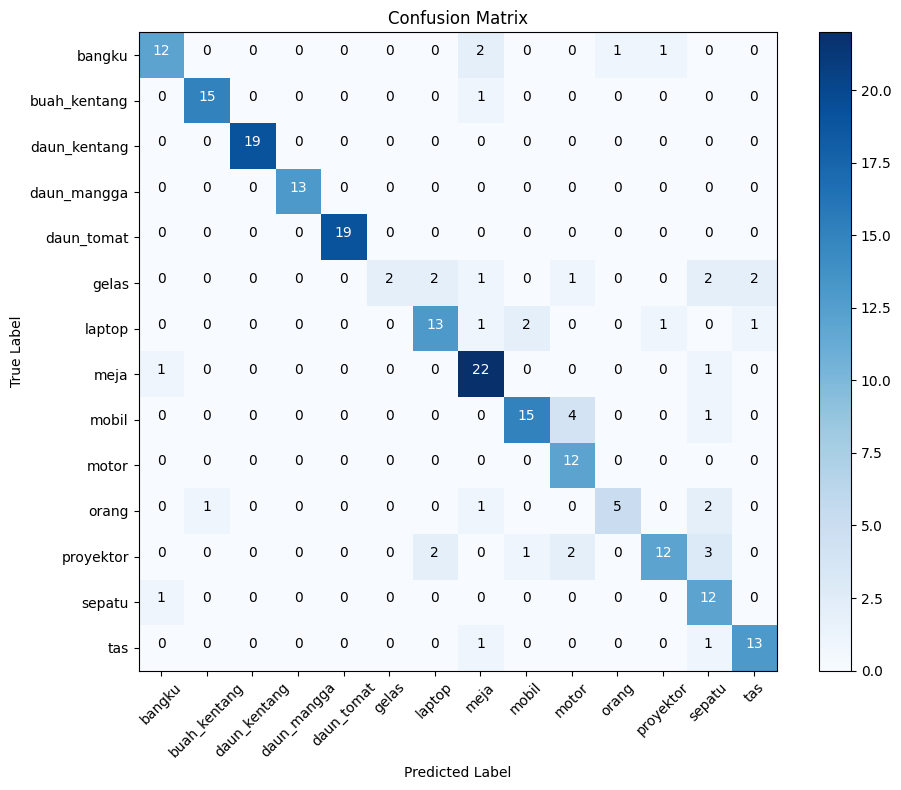

In [35]:
cm = confusion_matrix(y_true_model, y_pred_model)

def plot_confusion_matrix_model(cm, classes):
    fig_cm = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm.savefig('cm.png', dpi=300)

plot_confusion_matrix_model(cm, class_names)
plt.show()

## c. Precision, Recall, dan F1-Score

In [37]:
print(classification_report(y_true_model, y_pred_model, target_names=class_names))

              precision    recall  f1-score   support

      bangku       0.86      0.75      0.80        16
buah_kentang       0.94      0.94      0.94        16
daun_kentang       1.00      1.00      1.00        19
 daun_mangga       1.00      1.00      1.00        13
  daun_tomat       1.00      1.00      1.00        19
       gelas       1.00      0.20      0.33        10
      laptop       0.76      0.72      0.74        18
        meja       0.76      0.92      0.83        24
       mobil       0.83      0.75      0.79        20
       motor       0.63      1.00      0.77        12
       orang       0.83      0.56      0.67         9
   proyektor       0.86      0.60      0.71        20
      sepatu       0.55      0.92      0.69        13
         tas       0.81      0.87      0.84        15

    accuracy                           0.82       224
   macro avg       0.85      0.80      0.79       224
weighted avg       0.85      0.82      0.81       224



# VI. Export Model

In [39]:
model_cnn.save(f"models/model_object_classifier.keras")

In [40]:
model_cnn.save(f"models/model_object_classifier.h5")